In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from GASModels.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution

In [2]:
xls = pd.read_excel('data/Energia Sudeste.xls')

In [3]:
dynamics = Dynamics(
    distribution = GammaLogLinkDistribution(),
    n = len(xls['data']),
    components = None,
    time_varying_indices = [0],
    fixed_params_indices = [1],
    args = [0.05, 0.02]
)

In [4]:
dynamics.objective([0.02, 10.0, 0.00], xls['energia'])

np.float64(3945.436553039453)

In [5]:
minimize(dynamics.objective, [0.02, 10.0, 0.00], args=xls['energia'], method='L-BFGS-B', bounds=[(-2.0, 2.0), (0.0, None), (0.0, None)])

c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:21: RuntimeWarning: overflow encountered in exp
  scale = np.exp(lambda_ - alpha)  # theta = exp(lambda - alpha)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:49: RuntimeWarning: overflow encountered in exp
  dL_dlambda = np.exp(alpha) * (y / np.exp(lambda_) - 1)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:56: RuntimeWarning: overflow encountered in exp
  - y / np.exp(lambda_)
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 3733.6608477852674
        x: [ 2.927e-02  9.953e+00  9.989e-01]
      nit: 2
      jac: [-4.744e+02  2.484e+01 -1.991e+02]
     nfev: 24
     njev: 6
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [ ]:
np.exp(0.998) * (y / np.exp(9.953) - 1)

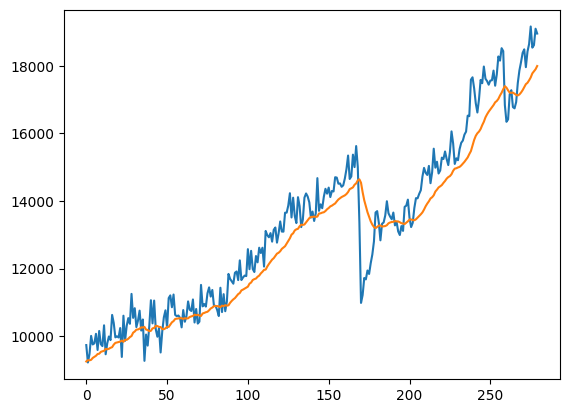

In [12]:
plt.plot(xls['energia'][100:].values)
plt.plot(y[100:])

In [8]:
y = dynamics.fit_in_sample([2.927e-02, 9.953, 0.998], xls['energia'])